<a href="https://colab.research.google.com/github/saudjabarali/ML_Grind/blob/main/Machine_Learning_Practices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [12]:
df=pd.read_csv("neo.csv")
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [13]:
df.isnull().sum

<bound method DataFrame.sum of           id   name  est_diameter_min  est_diameter_max  relative_velocity  \
0      False  False             False             False              False   
1      False  False             False             False              False   
2      False  False             False             False              False   
3      False  False             False             False              False   
4      False  False             False             False              False   
...      ...    ...               ...               ...                ...   
90831  False  False             False             False              False   
90832  False  False             False             False              False   
90833  False  False             False             False              False   
90834  False  False             False             False              False   
90835  False  False             False             False              False   

       miss_distance  orbiting_body  sentry_object  absolute_magnitude  \
0              False          False          False               False   
1              False          False          False               False   
2              False          False          False               False   
3              False          False          False               False   
4              False          False          False               False   
...              ...            ...            ...                 ...   
90831          False          False          False               False   
90832          False          False          False               False   
90833          False          False          False               False   
90834          False          False          False               False   
90835          False          False          False               False   

       hazardous  
0          False  
1          False  
2          False  
3          False  
4          False  
...          ...  
90831      False  
90832      False  
90833      False  
90834      False  
90835      False  

[90836 rows x 10 columns]>

In [14]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [15]:
print(df[df['hazardous']==True].count())
print(df[df['hazardous']==False].count())
print(df.count())

id                    8840
name                  8840
est_diameter_min      8840
est_diameter_max      8840
relative_velocity     8840
miss_distance         8840
orbiting_body         8840
sentry_object         8840
absolute_magnitude    8840
hazardous             8840
dtype: int64
id                    81996
name                  81996
est_diameter_min      81996
est_diameter_max      81996
relative_velocity     81996
miss_distance         81996
orbiting_body         81996
sentry_object         81996
absolute_magnitude    81996
hazardous             81996
dtype: int64
id                    90836
name                  90836
est_diameter_min      90836
est_diameter_max      90836
relative_velocity     90836
miss_distance         90836
orbiting_body         90836
sentry_object         90836
absolute_magnitude    90836
hazardous             90836
dtype: int64


In [16]:
df['hazardous']=df['hazardous'].astype(int)

In [17]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,0
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,1
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,0
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,0
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,1


In [18]:
print(df.columns)
cols=['est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance',
       'absolute_magnitude', 'hazardous']
print(cols)

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')
['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']


In [19]:
print(df["sentry_object"].unique())
print(df["orbiting_body"].unique())



[False]
['Earth']


In [20]:
df["sentry_object"]=df["sentry_object"].astype(int)
df["orbiting_body"]=(df["orbiting_body"]=="Earth").astype(int)

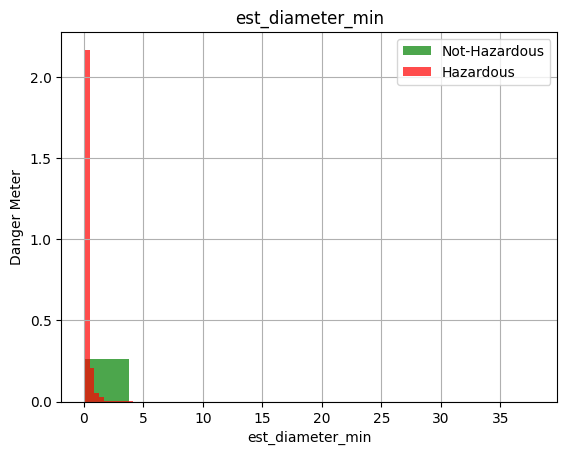

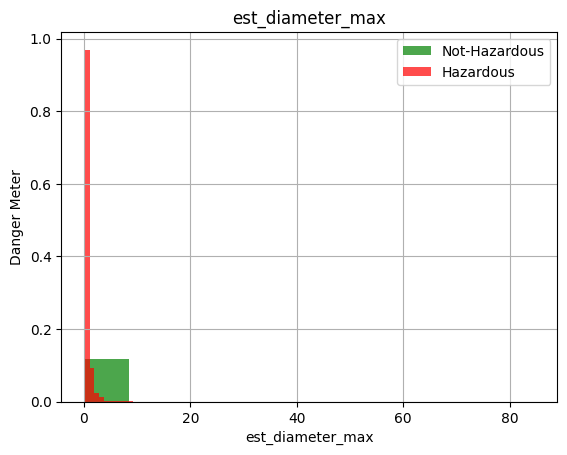

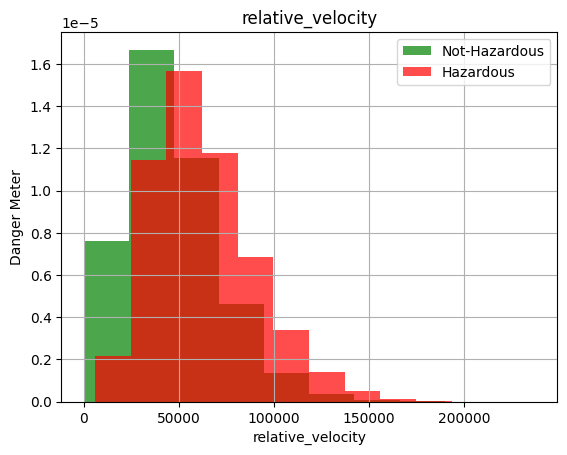

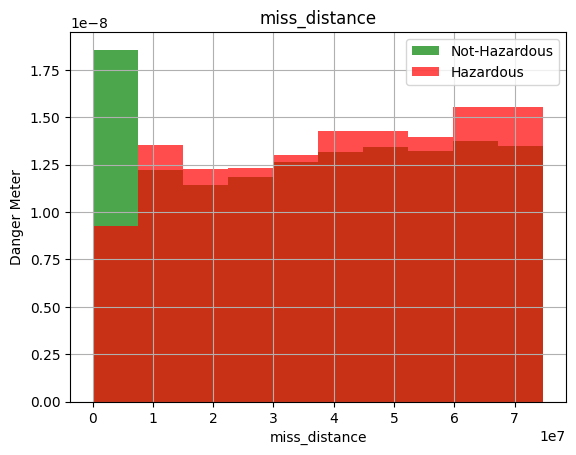

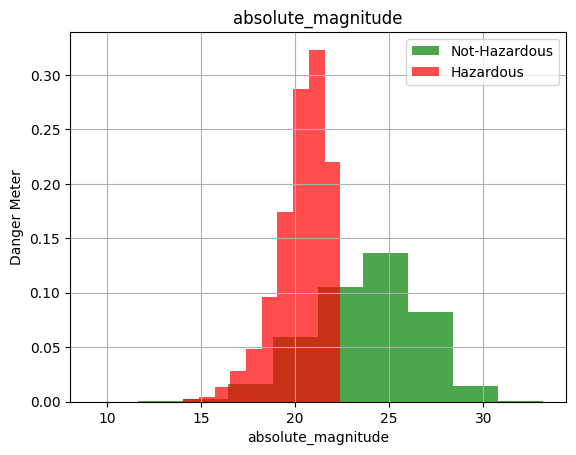

In [21]:
for label in cols[:-1]:
  plt.hist(df[df['hazardous']==0][label],color='green',label="Not-Hazardous",alpha=0.7,density=True)
  plt.hist(df[df['hazardous']==1][label],color='red',label="Hazardous",alpha=0.7,density=True)
  plt.grid()
  plt.title(label)
  plt.xlabel(label)
  plt.ylabel("Danger Meter")
  plt.legend()
  plt.show()

In [37]:
train,valid,test=np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])
print(train.shape,valid.shape,test.shape)

(54501, 10) (18167, 10) (18168, 10)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [23]:
(train['hazardous'] == 1).sum()

np.int64(5334)

In [24]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [34]:
def scale_dataset(dataframe,oversample=False):
  x=dataframe[dataframe.columns[:-1]].values
  y=dataframe[dataframe.columns[-1]].values
  scaler=StandardScaler()
  x=scaler.fit_transform(x)
  if oversample:
    ros=RandomOverSampler()
    x,y=ros.fit_resample(x,y)
  data=np.hstack((x,np.reshape(y,(-1,1))))
  return data,x,y

In [38]:
train_processed = train.drop(columns=['id', 'name'])
valid_processed = valid.drop(columns=['id', 'name'])
test_processed = test.drop(columns=['id', 'name'])

train,x_train,y_train=scale_dataset(train_processed,oversample=True)
valid,x_valid,y_valid=scale_dataset(valid_processed,oversample=False)
test,x_test,_y_test=scale_dataset(test_processed,oversample=False)

In [46]:
print((y_train==0).sum())
print((y_train==1).sum())

49202
49202


Let's Do the Cooking- K Nearest Neighbours


In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [51]:
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model=knn_model.fit(x_train,y_train)

y_pred=knn_model.predict(x_test)
print(classification_report(_y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     16383
           1       0.35      0.58      0.44      1785

    accuracy                           0.85     18168
   macro avg       0.65      0.73      0.68     18168
weighted avg       0.89      0.85      0.87     18168



In [54]:
knn_model=KNeighborsClassifier(n_neighbors=1)
knn_model=knn_model.fit(x_train,y_train)

y_pred=knn_model.predict(x_test)
print(classification_report(_y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     16383
           1       0.39      0.39      0.39      1785

    accuracy                           0.88     18168
   macro avg       0.66      0.66      0.66     18168
weighted avg       0.88      0.88      0.88     18168



Naive Bayes


In [57]:
from sklearn.naive_bayes import GaussianNB

In [58]:
nb_model=GaussianNB()
nb_model=nb_model.fit(x_train,y_train)

y_pred=nb_model.predict(x_test)
print(classification_report(_y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87     16383
           1       0.29      0.81      0.43      1785

    accuracy                           0.79     18168
   macro avg       0.63      0.80      0.65     18168
weighted avg       0.91      0.79      0.83     18168



Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression

In [62]:
lr_model=LogisticRegression()
lr_model=lr_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_test)
print(classification_report(_y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.77      0.86     16383
           1       0.30      0.92      0.45      1785

    accuracy                           0.78     18168
   macro avg       0.65      0.85      0.66     18168
weighted avg       0.92      0.78      0.82     18168



Support Vector Machine

In [ ]:
from sklearn.svm import scv
